In [1]:
from pathlib import Path
import sys
import os
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
RAW_DIR = DATA_DIR / "raw"
LABELS_PATH = DATA_DIR / "labels.csv"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

from src.parser import collect_image_candidates
from src.image_utils import (
    make_unique_filename,
    download_image,
    get_image_metadata,
    show_images_grid,
)

In [2]:
urls = [
    "https://eda.rambler.ru/media/recepty/pyat-horoshih-receptov-postnogo-pechenya",
    "https://eda.rambler.ru/recepty/zavtraki/sirniki-iz-tvoroga-18506",
    "https://books.toscrape.com/",
    "https://books.toscrape.com/catalogue/category/books/travel_2/index.html",
    "https://www.nationalgeographic.com/photography/article/nature-patterns-jon-mccormack-photography",
    "https://www.tsinghua.edu.cn/en/Campus/Student_Life/Arts___Culture.htm",
    "https://scrapeme.live/shop/Charmander/"
]

In [3]:
all_dfs = []

for idx, url in enumerate(urls, start=1):
    print(f"[{idx}/{len(urls)}] Collecting candidates for: {url}")

    page_stub = f"page_{idx:02d}"

    page_csv_path = INTERIM_DIR / f"{page_stub}_candidates.csv"
    page_json_path = INTERIM_DIR / f"{page_stub}_candidates.json"

    df = collect_image_candidates(
        url=url,
        save_csv_path=str(page_csv_path),
        save_json_path=str(page_json_path),
    )

    if not df.empty:
        df["page_stub"] = page_stub
        df["global_candidate_id"] = df["page_stub"] + "_" + df["candidate_id"]
    else:
        df["page_stub"] = []
        df["global_candidate_id"] = []

    print(f"Found {len(df)} candidates")
    print(f"Saved page CSV:  {page_csv_path}")
    print(f"Saved page JSON: {page_json_path}")

    all_dfs.append(df)

if all_dfs:
    candidates_df = pd.concat(all_dfs, ignore_index=True)
else:
    candidates_df = pd.DataFrame()

final_csv_path = INTERIM_DIR / "all_candidates.csv"
final_json_path = INTERIM_DIR / "all_candidates.json"

candidates_df.to_csv(final_csv_path, index=False, encoding="utf-8")
candidates_df.to_json(final_json_path, orient="records", force_ascii=False, indent=2)

print(f"Total candidates: {len(candidates_df)}")
print(f"Saved final CSV:  {final_csv_path}")
print(f"Saved final JSON: {final_json_path}")

candidates_df.head(20)

[1/7] Collecting candidates for: https://eda.rambler.ru/media/recepty/pyat-horoshih-receptov-postnogo-pechenya
Found 143 candidates
Saved page CSV:  c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\page_01_candidates.csv
Saved page JSON: c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\page_01_candidates.json
[2/7] Collecting candidates for: https://eda.rambler.ru/recepty/zavtraki/sirniki-iz-tvoroga-18506
Found 162 candidates
Saved page CSV:  c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\page_02_candidates.csv
Saved page JSON: c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\page_02_candidates.json
[3/7] Collecting candidates for: https://books.toscrape.com/
Found 20 candidates
Saved page CSV:  c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\page_03_candidates.csv
Saved page JSON: c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\page_03_candidates.json
[4/7] Collecting candidates for: https://books.toscrape.com

,page_url,image_url,source_attr,alt_text,tag_index,width_attr,height_attr,domain,file_name,candidate_id,page_stub,global_candidate_id
0,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/105674087,src,,0,,,mc.yandex.ru,105674087,cand_000000,page_01,page_01_cand_000000
1,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/27509004,src,,1,,,mc.yandex.ru,27509004,cand_000001,page_01,page_01_cand_000001
2,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/26649402,src,,2,,,mc.yandex.ru,26649402,cand_000002,page_01,page_01_cand_000002
3,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=2635991,src,Счетчик top100,3,,,counter.rambler.ru,top100.cnt,cand_000003,page_01,page_01_cand_000003
4,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=7728281,src,Счетчик top100,4,,,counter.rambler.ru,top100.cnt,cand_000004,page_01,page_01_cand_000004
5,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****afisha_ru/r...,src,,5,1,1,www.tns-counter.ru,,cand_000005,page_01,page_01_cand_000005
6,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,src,,6,1,1,www.tns-counter.ru,,cand_000006,page_01,page_01_cand_000006
7,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,src,,7,1,1,www.tns-counter.ru,,cand_000007,page_01,page_01_cand_000007
8,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,src,Иконка книги рецептов,8,,,eda.rambler.ru,rambler-favorites-bd704f5a077fe3675a33743723c2...,cand_000008,page_01,page_01_cand_000008
9,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,src,Иконка добавить рецепт,9,,,eda.rambler.ru,rambler-recipes-a1c77bb63384486ec36eb950f27020...,cand_000009,page_01,page_01_cand_000009


In [4]:
download_records = []

for row in candidates_df.itertuples(index=False):
    page_stub = row.page_stub
    global_candidate_id = row.global_candidate_id
    image_url = row.image_url

    page_raw_dir = RAW_DIR / page_stub
    local_file_name = make_unique_filename(
        image_url=image_url,
        candidate_id=global_candidate_id,
    )
    local_path = page_raw_dir / local_file_name

    download_ok, download_error = download_image(
        image_url=image_url,
        save_path=local_path,
    )

    record = {
        "candidate_id": global_candidate_id,
        "page_stub": page_stub,
        "page_url": row.page_url,
        "image_url": row.image_url,
        "source_attr": row.source_attr,
        "alt_text": row.alt_text,
        "tag_index": row.tag_index,
        "width_attr": row.width_attr,
        "height_attr": row.height_attr,
        "domain": row.domain,
        "file_name": row.file_name,
        "local_file_name": local_file_name,
        "local_path": str(local_path),
        "download_ok": download_ok,
        "download_error": download_error,
    }

    if download_ok:
        record.update(get_image_metadata(local_path))
    else:
        record.update({
            "is_valid_image": False,
            "width": None,
            "height": None,
            "format": None,
            "mode": None,
            "file_size_bytes": None,
            "area": None,
            "aspect_ratio": None,
            "image_error": download_error,
        })

    download_records.append(record)

dataset_df = pd.DataFrame(download_records)
dataset_df.head(20)

,candidate_id,page_stub,page_url,image_url,source_attr,alt_text,tag_index,width_attr,height_attr,domain,...,download_error,is_valid_image,width,height,format,mode,file_size_bytes,area,aspect_ratio,image_error
0,page_01_cand_000000,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/105674087,src,,0,,,mc.yandex.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
1,page_01_cand_000001,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/27509004,src,,1,,,mc.yandex.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
2,page_01_cand_000002,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/26649402,src,,2,,,mc.yandex.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
3,page_01_cand_000003,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=2635991,src,Счетчик top100,3,,,counter.rambler.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
4,page_01_cand_000004,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=7728281,src,Счетчик top100,4,,,counter.rambler.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
5,page_01_cand_000005,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****afisha_ru/r...,src,,5,1,1,www.tns-counter.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
6,page_01_cand_000006,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,src,,6,1,1,www.tns-counter.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
7,page_01_cand_000007,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,src,,7,1,1,www.tns-counter.ru,...,,True,1.0,1.0,GIF,P,43,1.0,1.000000,
8,page_01_cand_000008,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,src,Иконка книги рецептов,8,,,eda.rambler.ru,...,,False,NaN,NaN,None,None,11805,NaN,NaN,Cannot open image
9,page_01_cand_000009,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,src,Иконка добавить рецепт,9,,,eda.rambler.ru,...,,False,NaN,NaN,None,None,16151,NaN,NaN,Cannot open image


In [5]:
# только техническая очистка, без смысловой фильтрации
dataset_df = dataset_df.drop_duplicates(subset=["page_url", "image_url"]).reset_index(drop=True)

dataset_df["is_downloaded_and_valid"] = (
    dataset_df["download_ok"].fillna(False) &
    dataset_df["is_valid_image"].fillna(False)
)

raw_dataset_csv = INTERIM_DIR / "all_candidates_downloaded.csv"
raw_dataset_json = INTERIM_DIR / "all_candidates_downloaded.json"

dataset_df.to_csv(raw_dataset_csv, index=False, encoding="utf-8")
dataset_df.to_json(raw_dataset_json, orient="records", force_ascii=False, indent=2)

print("All rows:", len(dataset_df))
print("Downloaded and valid:", int(dataset_df["is_downloaded_and_valid"].sum()))
print("Saved:", raw_dataset_csv)
print("Saved:", raw_dataset_json)

dataset_df.head(20)

All rows: 527
Downloaded and valid: 523
Saved: c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\all_candidates_downloaded.csv
Saved: c:\Users\Masha\ML_Projects\Photo-Classification\data\interim\all_candidates_downloaded.json


,candidate_id,page_stub,page_url,image_url,source_attr,alt_text,tag_index,width_attr,height_attr,domain,...,is_valid_image,width,height,format,mode,file_size_bytes,area,aspect_ratio,image_error,is_downloaded_and_valid
0,page_01_cand_000000,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/105674087,src,,0,,,mc.yandex.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
1,page_01_cand_000001,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/27509004,src,,1,,,mc.yandex.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
2,page_01_cand_000002,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/26649402,src,,2,,,mc.yandex.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
3,page_01_cand_000003,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=2635991,src,Счетчик top100,3,,,counter.rambler.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
4,page_01_cand_000004,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=7728281,src,Счетчик top100,4,,,counter.rambler.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
5,page_01_cand_000005,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****afisha_ru/r...,src,,5,1,1,www.tns-counter.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
6,page_01_cand_000006,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,src,,6,1,1,www.tns-counter.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
7,page_01_cand_000007,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,src,,7,1,1,www.tns-counter.ru,...,True,1.0,1.0,GIF,P,43,1.0,1.000000,,True
8,page_01_cand_000008,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,src,Иконка книги рецептов,8,,,eda.rambler.ru,...,False,NaN,NaN,None,None,11805,NaN,NaN,Cannot open image,False
9,page_01_cand_000009,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,src,Иконка добавить рецепт,9,,,eda.rambler.ru,...,False,NaN,NaN,None,None,16151,NaN,NaN,Cannot open image,False


In [6]:
def build_labels_table(dataset_df: pd.DataFrame, labels_path: Path) -> pd.DataFrame:
    labels_df = dataset_df[
        [
            "candidate_id",
            "page_stub",
            "page_url",
            "image_url",
            "local_path",
            "domain",
            "file_name",
            "width",
            "height",
            "format",
            "mode",
            "file_size_bytes",
            "area",
            "aspect_ratio",
            "is_downloaded_and_valid",
        ]
    ].copy()

    labels_df["label"] = ""
    labels_df["split"] = ""

    if labels_path.exists():
        old_labels_df = pd.read_csv(labels_path)

        keep_cols = ["candidate_id", "label", "split"]
        keep_cols = [col for col in keep_cols if col in old_labels_df.columns]

        if keep_cols:
            old_small = old_labels_df[keep_cols].copy()

            labels_df = labels_df.drop(columns=["label", "split"], errors="ignore")
            labels_df = labels_df.merge(old_small, on="candidate_id", how="left")

            for col in ["label", "split"]:
                if col not in labels_df.columns:
                    labels_df[col] = ""
                labels_df[col] = labels_df[col].fillna("")

    return labels_df


labels_df = build_labels_table(dataset_df, LABELS_PATH)
labels_df.to_csv(LABELS_PATH, index=False, encoding="utf-8")

print(f"Saved labels file: {LABELS_PATH}")
labels_df.head(20)

Saved labels file: c:\Users\Masha\ML_Projects\Photo-Classification\data\labels.csv


,candidate_id,page_stub,page_url,image_url,local_path,domain,file_name,width,height,format,mode,file_size_bytes,area,aspect_ratio,is_downloaded_and_valid,label,split
0,page_01_cand_000000,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/105674087,c:\Users\Masha\ML_Projects\Photo-Classificatio...,mc.yandex.ru,105674087,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
1,page_01_cand_000001,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/27509004,c:\Users\Masha\ML_Projects\Photo-Classificatio...,mc.yandex.ru,27509004,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
2,page_01_cand_000002,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/26649402,c:\Users\Masha\ML_Projects\Photo-Classificatio...,mc.yandex.ru,26649402,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
3,page_01_cand_000003,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=2635991,c:\Users\Masha\ML_Projects\Photo-Classificatio...,counter.rambler.ru,top100.cnt,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
4,page_01_cand_000004,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=7728281,c:\Users\Masha\ML_Projects\Photo-Classificatio...,counter.rambler.ru,top100.cnt,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
5,page_01_cand_000005,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****afisha_ru/r...,c:\Users\Masha\ML_Projects\Photo-Classificatio...,www.tns-counter.ru,,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
6,page_01_cand_000006,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,c:\Users\Masha\ML_Projects\Photo-Classificatio...,www.tns-counter.ru,,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
7,page_01_cand_000007,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://www.tns-counter.ru/V13a****rambler_ad/...,c:\Users\Masha\ML_Projects\Photo-Classificatio...,www.tns-counter.ru,,1.0,1.0,GIF,P,43,1.0,1.000000,True,non_content,
8,page_01_cand_000008,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,c:\Users\Masha\ML_Projects\Photo-Classificatio...,eda.rambler.ru,rambler-favorites-bd704f5a077fe3675a33743723c2...,NaN,NaN,None,None,11805,NaN,NaN,False,non_content,
9,page_01_cand_000009,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://eda.rambler.ru/_next/static/images/ram...,c:\Users\Masha\ML_Projects\Photo-Classificatio...,eda.rambler.ru,rambler-recipes-a1c77bb63384486ec36eb950f27020...,NaN,NaN,None,None,16151,NaN,NaN,False,non_content,


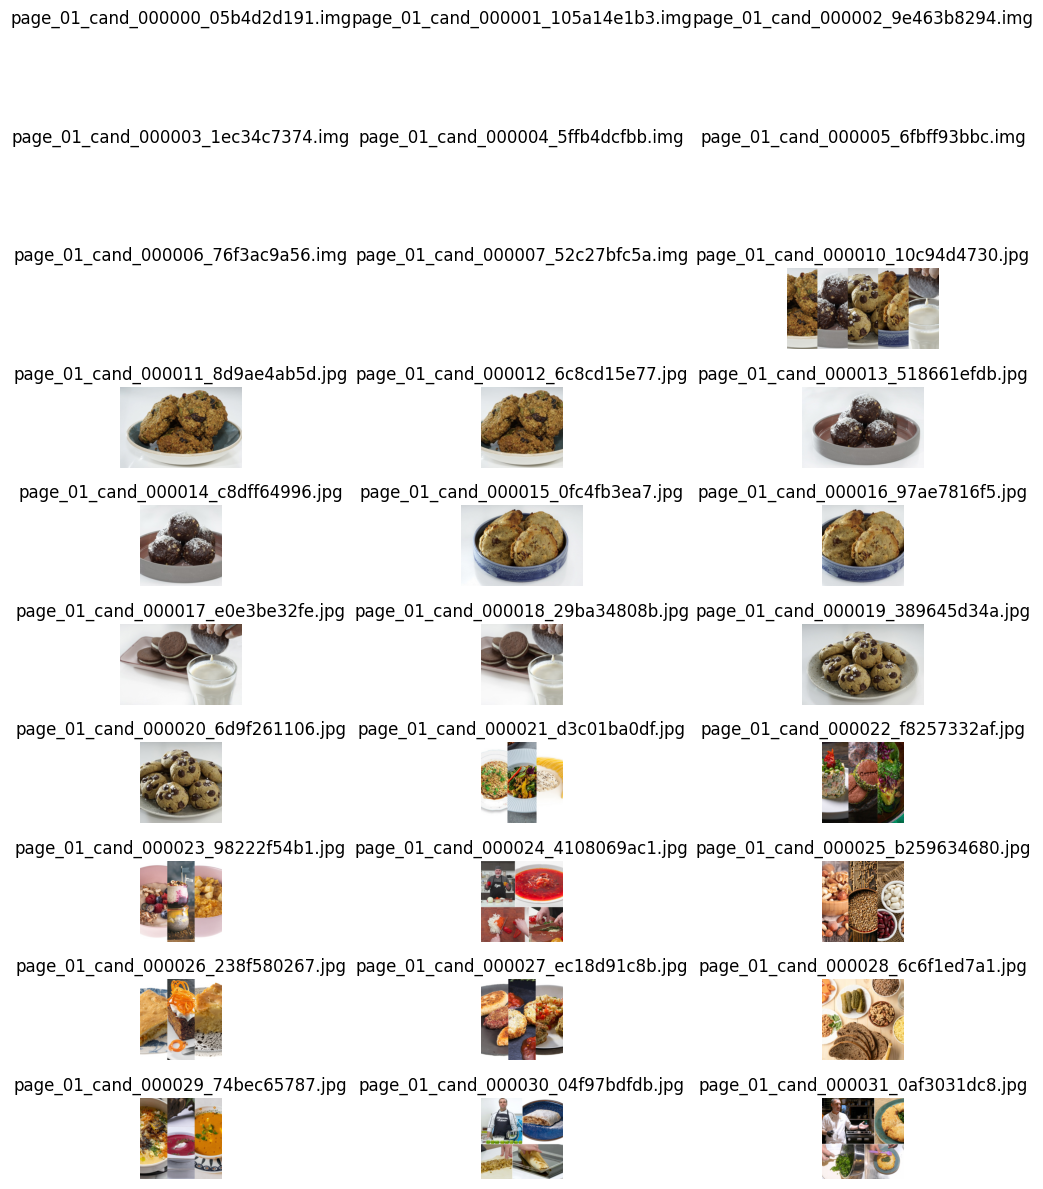

In [7]:
valid_paths = labels_df.loc[labels_df["is_downloaded_and_valid"], "local_path"].tolist()
show_images_grid(valid_paths, n=30)

In [8]:
SUSPICIOUS_DOMAINS = {
    "mc.yandex.ru",
    "counter.rambler.ru",
    "www.tns-counter.ru",
}

UI_KEYWORDS = (
    "icon",
    "logo",
    "sprite",
    "banner",
    "ads",
    "advert",
    "promo",
    "button",
    "btn",
    "favicon",
    "avatar",
    "counter",
    "pixel",
    "share",
    "social",
    "placeholder",
)


def add_helper_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    width_num = pd.to_numeric(df["width"], errors="coerce")
    height_num = pd.to_numeric(df["height"], errors="coerce")

    df["is_tiny"] = ((width_num <= 5) & (height_num <= 5)).fillna(False)
    df["is_suspicious_domain"] = df["domain"].fillna("").isin(SUSPICIOUS_DOMAINS)

    keyword_text = (
        df["file_name"].fillna("").astype(str) + " " +
        df["image_url"].fillna("").astype(str) + " " +
        df["page_url"].fillna("").astype(str)
    ).str.lower()

    df["has_ui_keyword"] = keyword_text.apply(
        lambda s: any(keyword in s for keyword in UI_KEYWORDS)
    )

    return df


labels_df = add_helper_flags(labels_df)
labels_df.to_csv(LABELS_PATH, index=False, encoding="utf-8")

labels_df.head()

,candidate_id,page_stub,page_url,image_url,local_path,domain,file_name,width,height,format,mode,file_size_bytes,area,aspect_ratio,is_downloaded_and_valid,label,split,is_tiny,is_suspicious_domain,has_ui_keyword
0,page_01_cand_000000,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/105674087,c:\Users\Masha\ML_Projects\Photo-Classificatio...,mc.yandex.ru,105674087,1.0,1.0,GIF,P,43,1.0,1.0,True,non_content,,True,True,False
1,page_01_cand_000001,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/27509004,c:\Users\Masha\ML_Projects\Photo-Classificatio...,mc.yandex.ru,27509004,1.0,1.0,GIF,P,43,1.0,1.0,True,non_content,,True,True,False
2,page_01_cand_000002,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://mc.yandex.ru/watch/26649402,c:\Users\Masha\ML_Projects\Photo-Classificatio...,mc.yandex.ru,26649402,1.0,1.0,GIF,P,43,1.0,1.0,True,non_content,,True,True,False
3,page_01_cand_000003,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=2635991,c:\Users\Masha\ML_Projects\Photo-Classificatio...,counter.rambler.ru,top100.cnt,1.0,1.0,GIF,P,43,1.0,1.0,True,non_content,,True,True,True
4,page_01_cand_000004,page_01,https://eda.rambler.ru/media/recepty/pyat-horo...,https://counter.rambler.ru/top100.cnt?pid=7728281,c:\Users\Masha\ML_Projects\Photo-Classificatio...,counter.rambler.ru,top100.cnt,1.0,1.0,GIF,P,43,1.0,1.0,True,non_content,,True,True,True


In [9]:
def get_unlabeled_batch(df: pd.DataFrame, start: int = 0, batch_size: int = 20) -> pd.DataFrame:
    work_df = df[df["label"].fillna("") == ""].copy()
    return work_df.iloc[start:start + batch_size].copy()


batch_df = get_unlabeled_batch(labels_df, start=0, batch_size=20)

batch_df[
    [
        "candidate_id",
        "page_stub",
        "file_name",
        "domain",
        "width",
        "height",
        "format",
        "is_downloaded_and_valid",
        "is_tiny",
        "is_suspicious_domain",
        "has_ui_keyword",
        "label",
    ]
]

,candidate_id,page_stub,file_name,domain,width,height,format,is_downloaded_and_valid,is_tiny,is_suspicious_domain,has_ui_keyword,label
525,page_07_cand_000024,page_07,002-350x350.png,scrapeme.live,350.0,350.0,PNG,True,False,False,True,
526,page_07_cand_000025,page_07,005-350x350.png,scrapeme.live,350.0,350.0,PNG,True,False,False,True,


In [10]:
from pathlib import Path
import matplotlib.pyplot as plt

from src.image_utils import safe_open_image


def show_labeling_batch(batch_df: pd.DataFrame) -> None:
    for _, row in batch_df.iterrows():
        print(f"candidate_id:         {row['candidate_id']}")
        print(f"page_stub:            {row['page_stub']}")
        print(f"page_url:             {row['page_url']}")
        print(f"image_url:            {row['image_url']}")
        print(f"local_path:           {row['local_path']}")
        print(f"domain:               {row['domain']}")
        print(f"file_name:            {row['file_name']}")
        print(f"size:                 {row['width']} x {row['height']}")
        print(f"format:               {row['format']}")
        print(f"file_size_bytes:      {row['file_size_bytes']}")
        print(f"is_downloaded_valid:  {row['is_downloaded_and_valid']}")
        print(f"is_tiny:              {row['is_tiny']}")
        print(f"is_suspicious_domain: {row['is_suspicious_domain']}")
        print(f"has_ui_keyword:       {row['has_ui_keyword']}")
        print(f"current_label:        {row['label']}")

        local_path = row["local_path"]

        if isinstance(local_path, str) and local_path and Path(local_path).exists():
            img = safe_open_image(Path(local_path))

            if img is None:
                print("Cannot open image with PIL.")
                continue

            plt.figure(figsize=(6, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        else:
            print("Image file missing or invalid.")

candidate_id:         page_07_cand_000024
page_stub:            page_07
page_url:             https://scrapeme.live/shop/Charmander/
image_url:            https://scrapeme.live/wp-content/uploads/2018/08/002-350x350.png
local_path:           c:\Users\Masha\ML_Projects\Photo-Classification\data\raw\page_07\page_07_cand_000024_3ab2b9bba8.png
domain:               scrapeme.live
file_name:            002-350x350.png
size:                 350.0 x 350.0
format:               PNG
file_size_bytes:      126920
is_downloaded_valid:  True
is_tiny:              False
is_suspicious_domain: False
has_ui_keyword:       True
current_label:        


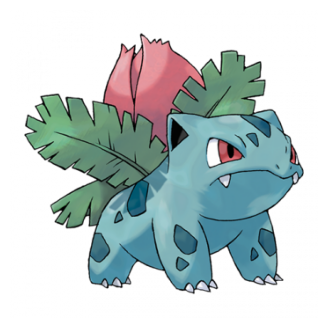

candidate_id:         page_07_cand_000025
page_stub:            page_07
page_url:             https://scrapeme.live/shop/Charmander/
image_url:            https://scrapeme.live/wp-content/uploads/2018/08/005-350x350.png
local_path:           c:\Users\Masha\ML_Projects\Photo-Classification\data\raw\page_07\page_07_cand_000025_fce4322a99.png
domain:               scrapeme.live
file_name:            005-350x350.png
size:                 350.0 x 350.0
format:               PNG
file_size_bytes:      88618
is_downloaded_valid:  True
is_tiny:              False
is_suspicious_domain: False
has_ui_keyword:       True
current_label:        


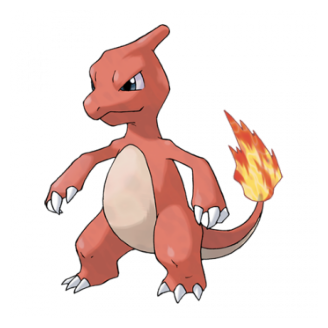

In [11]:
show_labeling_batch(batch_df)

In [12]:
manual_labels = {}

def mark_range(page_stub: str, start: int, end: int, label: str):
    for i in range(start, end + 1):
        candidate_id = f"{page_stub}_cand_{i:06d}"
        manual_labels[candidate_id] = label

# page_01
mark_range("page_01", 0, 9, "non_content")
mark_range("page_01", 10, 20, "content")
mark_range("page_01", 21, 37, "non_content")
mark_range("page_01", 38, 57, "content")
mark_range("page_01", 58, 142, "non_content")

# page_02
mark_range("page_02", 0, 9, "non_content")
mark_range("page_02", 10, 15, "content")
mark_range("page_02", 16, 16, "non_content")
mark_range("page_02", 17, 26, "content")
mark_range("page_02", 27, 30, "non_content")
mark_range("page_02", 31, 101, "content")
mark_range("page_02", 102, 111, "non_content")
mark_range("page_02", 112, 161, "content")

# page_03
mark_range("page_03", 0, 19, "content")

# page_04
mark_range("page_04", 0, 10, "content")

# page_05
mark_range("page_05", 0, 9, "content")
mark_range("page_05", 10, 12, "non_content")
mark_range("page_05", 13, 13, "content")
mark_range("page_05", 14, 18, "non_content")
mark_range("page_05", 19, 98, "content")
mark_range("page_05", 99, 110, "non_content")
mark_range("page_05", 111, 116, "content")
mark_range("page_05", 117, 158, "non_content")

# page_06
mark_range("page_06", 0, 0, "non_content")
mark_range("page_06", 1, 4, "content")
mark_range("page_06", 5, 5, "non_content")

# page_07
mark_range("page_07", 0, 5, "content")
mark_range("page_07", 6, 25, "non_content")

for candidate_id, label_value in manual_labels.items():
    labels_df.loc[labels_df["candidate_id"] == candidate_id, "label"] = label_value

labels_df.to_csv(LABELS_PATH, index=False, encoding="utf-8")

print(f"Saved labels to: {LABELS_PATH}")
labels_df["label"].value_counts(dropna=False)

Saved labels to: c:\Users\Masha\ML_Projects\Photo-Classification\data\labels.csv


label
content        306
non_content    221
Name: count, dtype: int64

In [13]:
import shutil

LABELED_DIR = DATA_DIR / "labeled"
CONTENT_DIR = LABELED_DIR / "content"
NON_CONTENT_DIR = LABELED_DIR / "non_content"

CONTENT_DIR.mkdir(parents=True, exist_ok=True)
NON_CONTENT_DIR.mkdir(parents=True, exist_ok=True)


def export_labeled_images(df: pd.DataFrame) -> None:
    labeled_only = df[df["label"].isin(["content", "non_content"])].copy()

    copied = 0
    skipped = 0

    for _, row in labeled_only.iterrows():
        local_path = row["local_path"]
        label = row["label"]

        if not isinstance(local_path, str) or not local_path or not Path(local_path).exists():
            skipped += 1
            continue

        src_path = Path(local_path)
        dst_dir = CONTENT_DIR if label == "content" else NON_CONTENT_DIR
        dst_path = dst_dir / src_path.name

        if not dst_path.exists():
            shutil.copy2(src_path, dst_path)
            copied += 1

    print(f"Copied: {copied}")
    print(f"Skipped: {skipped}")

In [14]:
export_labeled_images(labels_df)

Copied: 22
Skipped: 0
